In [1]:
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df =pd.read_csv('/content/placement.csv')

In [6]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


# Steps

0. Preprocess + EDA + Feature Selection
1. Extract input and output cols
2. Scale the values
3. Train test split
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model bold text




In [7]:
df= df.iloc[:,1:]

In [8]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


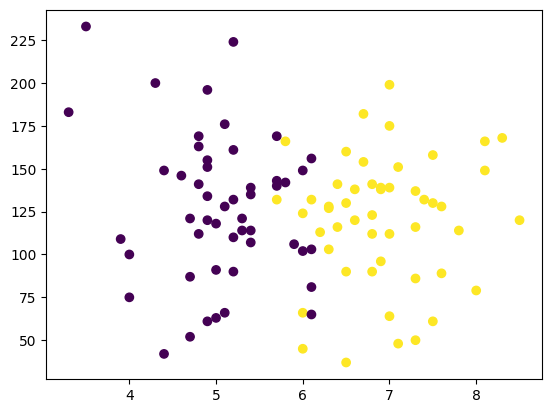

In [12]:
plt.scatter(df['cgpa'], df ['iq'],c=df['placement'] )

In [22]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [14]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [23]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [27]:
x_train

,cgpa,iq
86,5.1,128.0
1,5.9,106.0
49,5.4,135.0
53,8.3,168.0
74,6.7,154.0
...,...,...
99,6.2,113.0
3,7.4,132.0
14,6.1,103.0
60,6.9,139.0


In [28]:
y_train

,placement
86,0
1,0
49,0
53,1
74,1
...,...
99,1
3,1
14,0
60,1


In [29]:
x_test

,cgpa,iq
50,3.5,233.0
33,6.0,149.0
73,4.9,61.0
24,4.7,121.0
21,7.1,151.0
46,5.3,114.0
66,6.9,96.0
15,5.1,176.0
8,6.1,156.0
4,5.8,142.0


In [30]:
y_test

,placement
50,0
33,0
73,0
24,0
21,1
46,0
66,1
15,0
8,0
4,0


In [31]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
x_train=Scaler.fit_transform(x_train)

In [32]:
x_train

array([[-0.82605217,  0.16071907],
       [-0.12385906, -0.4065247 ],
       [-0.56272976,  0.34120572],
       [ 1.98272027,  1.19207136],
       [ 0.57833405,  0.83109806],
       [ 1.10497888, -0.14868662],
       [-1.00160045, -0.04555139],
       [ 1.28052716,  0.93423329],
       [-0.73827804,  1.01158471],
       [ 0.84165647,  0.44434095],
       [-0.03608492, -0.50965993],
       [ 0.22723749,  0.16071907],
       [ 0.66610819,  0.03180003],
       [ 0.22723749, -0.48387612],
       [-1.00160045,  0.75374663],
       [-1.52824529,  2.01715319],
       [-1.87934184, -0.32917327],
       [-0.03608492, -1.43787699],
       [ 0.57833405,  1.55304466],
       [ 0.49055991, -0.04555139],
       [ 2.15826855, -0.04555139],
       [ 0.05168922, -1.4636608 ],
       [ 1.28052716, -1.56679603],
       [-0.91382631, -0.79328181],
       [-0.29940734,  0.47012475],
       [ 0.84165647,  1.99136939],
       [-1.44047115,  0.70217902],
       [-1.00160045,  0.85688186],
       [ 0.05168922,

In [33]:
x_test=Scaler.transform(x_test)


In [34]:
x_test

array([[-2.2304384 ,  2.86801884],
       [-0.03608492,  0.70217902],
       [-1.00160045, -1.56679603],
       [-1.17714873, -0.01976759],
       [ 0.92943061,  0.75374663],
       [-0.6505039 , -0.20025424],
       [ 0.75388233, -0.66436277],
       [-0.82605217,  1.39834182],
       [ 0.05168922,  0.88266567],
       [-0.2116332 ,  0.52169237]])

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
clf=LogisticRegression()

In [38]:
clf.fit(x_train,y_train)

LogisticRegression()

In [39]:
y_pred = clf.predict(x_test)

In [40]:
y_test

,placement
50,0
33,0
73,0
24,0
21,1
46,0
66,1
15,0
8,0
4,0


In [41]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8

In [42]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

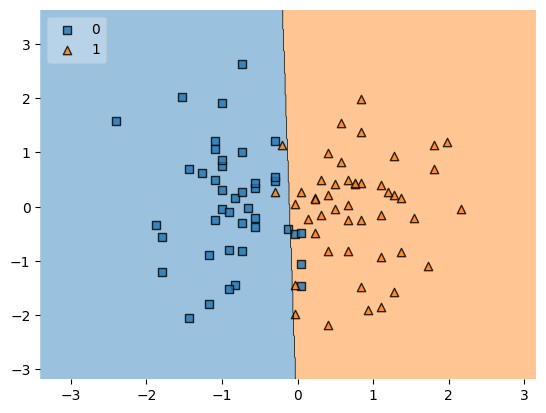

In [43]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)